# 8. BERT Regressor

Este notebook apresenta o processo de treinamento de um modelo de regressão baseado no BERTimbau para prever o parâmetro B de itens do ENEM a partir de seus enunciados. O fluxo inclui carregamento e limpeza dos dados, tokenização dos textos, preparação dos conjuntos de treino, validação e teste, definição do modelo de regressão e treinamento com acompanhamento de métricas (MSE e RMSE).


In [ ]:
# Importando bibliotecas para modelagem do BERT
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.nn.utils.clip_grad import clip_grad_norm_
from torch.utils.data import TensorDataset, DataLoader
from torcheval.metrics.functional import r2_score
from transformers import AutoTokenizer, AutoModel
from transformers.optimization import get_linear_schedule_with_warmup

In [ ]:
# Leitura dos dados pré-processados
cleaned_data = pd.read_csv("../data/final/cleaned_enem_data.csv").dropna()
cleaned_data.head()

,numero_questao,enunciado,alternativas,gabarito,questao,pc_amostra_acertos,ano,gabarito_texto,distratores,enunciado_tokens,gabarito_tokens,distratores_tokens,dificuldade
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,1,0.93,2009,"reduzir o desmatamento, mantendo-se, assim, o ...",reduzir o calor irradiado pela Terra mediante ...,atmosfera terrestre composta gases nitrogênio ...,reduzir desmatamento mantendo assim potencial ...,reduzir calor irradiado terra mediante substit...,-1.70677
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,2,0.40,2009,Estimativa de tempo necessário para metaboliza...,Concentração média de álcool no sangue ao long...,analise figura supondo necessário dar título f...,estimativa tempo necessário metabolizar difere...,concentração média álcool sangue longo dia var...,0.62043
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,3,0.40,2009,"induzir a imunidade, para proteger o organismo...",ser capaz de alterar o genoma do organismo por...,estima atualmente mundo milhões pessoas infect...,induzir imunidade proteger organismo contamina...,capaz alterar genoma organismo portador induzi...,2.07704
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,4,0.61,2009,os genótipos idênticos e os fenótipos diferentes.,os genótipos e os fenótipos idênticos.; difere...,experimento preparou conjunto plantas técnica ...,genótipos idênticos fenótipos diferentes,genótipos fenótipos idênticos diferenças genót...,0.11500
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,5,0.60,2009,"Kepler apresentou uma teoria científica que, g...","Ptolomeu apresentou as ideias mais valiosas, p...",linha tradição antiga astrônomo grego ptolomeu...,kepler apresentou teoria científica graças mét...,ptolomeu apresentou ideias valiosas serem anti...,0.21694


---

## 8.1. Funções Auxiliares


In [ ]:
# Iniciando Tokenizer do BERT em Português
tokenizer = AutoTokenizer.from_pretrained(
    "neuralmind/bert-base-portuguese-cased", do_lower_case=False
)

In [ ]:
# Convertendo os dados em DataLoader (Aceitos pelo Pytorch)
def create_dataloaders(inputs, masks, labels, batch_size):
    input_tensor = torch.tensor(inputs)
    mask_tensor = torch.tensor(masks)
    labels_tensor = torch.tensor(labels)

    dataset = TensorDataset(input_tensor, mask_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader

In [ ]:
# Função para Calcular o R2
def r2_score(outputs, labels):
    labels_mean = torch.mean(labels)
    ss_tot = torch.sum((labels - labels_mean) ** 2)
    ss_res = torch.sum((labels - outputs) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2

In [ ]:
# Função para treinamento do modelo BERT com Camada de Regressão e Early Stopping
def train_bert(
    model,
    optimizer,
    scheduler,
    loss_function,
    epochs,
    train_dataloader,
    test_dataloader,
    device,
    clip_value=2,
):
    # métricas de treino total (valor por época)
    loss_list = []
    rmse_list = []
    epoch_list = []

    # métricas de teste total (valor por época)
    test_loss_list = []
    test_rmse_list = []

    for epoch in range(epochs):

        # métricas de treino numa época (valor por batch)
        batch_loss_list = []
        batch_rmse_list = []

        print("\n-----")
        print("EPOCH:", epoch)
        best_loss = 1e10

        model.train()
        for step, batch in enumerate(train_dataloader):
            batch_inputs, batch_masks, batch_labels = tuple(b.to(device) for b in batch)
            model.zero_grad()
            outputs = model(batch_inputs, batch_masks)  # implement token ids later

            loss = loss_function(outputs.squeeze(), batch_labels.squeeze())
            rmse = torch.sqrt(loss)

            loss.backward()
            clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            scheduler.step()

            print(
                "   BATCH:",
                step,
                "   LOSS:",
                loss.cpu().detach().numpy(),
                "   RMSE:",
                rmse.cpu().detach().numpy(),
            )

            batch_loss_list.append(loss)
            batch_rmse_list.append(rmse)
            epoch_list.append(epoch)  ########

        # inicia variáveis de test loss e rmse
        test_loss = 0
        test_rmse = 0

        # para cada item do conjunto de teste, calcula mse e rmse daquela época
        model.eval()
        with torch.no_grad():
            for i, test_data in enumerate(test_dataloader):
                test_inputs, test_masks, test_labels = tuple(
                    b.to(device) for b in test_data
                )
                test_outputs = model(test_inputs, test_masks)
                test_loss += loss_function(
                    test_outputs.squeeze(), test_labels.squeeze()
                )
                test_rmse += torch.sqrt(test_loss)

        # calcula as médias das métricas de treino
        media_loss_treino = (sum(batch_loss_list)) / (len(batch_loss_list))
        media_rmse_treino = (sum(batch_rmse_list)) / (len(batch_rmse_list))
        loss_list.append((sum(batch_loss_list)) / (len(batch_loss_list)))
        rmse_list.append((sum(batch_rmse_list)) / (len(batch_rmse_list)))

        # calcula as médias das métricas de teste
        media_loss_teste = test_loss / (i + 1)
        media_rmse_teste = test_rmse / (i + 1)
        test_loss_list.append(media_loss_teste)
        test_rmse_list.append(media_rmse_teste)

        if media_loss_treino < best_loss:
            best_loss = media_loss_treino
            torch.save(
                model.state_dict(), "bert_model.pht"
            )

        print(
            "MSE  train:",
            media_loss_treino.cpu().detach().numpy(),
            "  test:",
            media_loss_teste.cpu().detach().numpy(),
        )
        print(
            "RMSE  train:",
            media_rmse_treino.cpu().detach().numpy(),
            "  test:",
            media_rmse_teste.cpu().detach().numpy(),
        )

    return model, loss_list, rmse_list, test_loss_list, test_rmse_list, best_loss

---

## 8.2. Modelo com Enunciado


In [ ]:
data = cleaned_data[["enunciado", "nu_param_B"]].dropna()
data.head(3)

,enunciado,nu_param_B
0,Para realizar o desentupimento de tubulações d...,1.13773
1,As redes de alta tensão para transmissão de en...,1.45214
2,A esquistossomose (barriga-dʼágua) caracteriza...,0.58402


### 8.2.1. Tokenização (BERTimbau)

In [ ]:
# Tokenizando os textos do enunciado
encoded_corpus = tokenizer(
    text=data.enunciado.tolist(),
    add_special_tokens=True,
    padding="max_length",
    truncation="longest_first",
    max_length=512,
    return_attention_mask=True,
)

# Coletando input_ids (features)
input_ids = encoded_corpus["input_ids"]
attention_mask = encoded_corpus["attention_mask"]

# Coletando labels (target)
labels = data.nu_param_B.to_numpy()

In [ ]:
# Separando dados para validação (20% para validação / 80% para treino e teste)
seed = 42

train_and_test_inputs, val_inputs, train_and_test_labels, val_labels = train_test_split(
    input_ids, labels, test_size=0.2, random_state=seed
)
train_and_test_masks, val_masks, _, _ = train_test_split(
    attention_mask, labels, test_size=0.2, random_state=seed
)

In [ ]:
# Separando treino e teste (10% dos dados para teste/ 90% para treino)

train_inputs, test_inputs, train_labels, test_labels = train_test_split(
    train_and_test_inputs, train_and_test_labels, test_size=0.1, random_state=seed
)
train_masks, test_masks, _, _ = train_test_split(
    train_and_test_masks, train_and_test_labels, test_size=0.1, random_state=seed
)

In [ ]:
batch_size = 8

# Convertendo os dados em dataloader (aceito pelo pytorch)
train_dataloader = create_dataloaders(
    train_inputs, train_masks, train_labels, batch_size
)
test_dataloader = create_dataloaders(test_inputs, test_masks, test_labels, batch_size)

### 8.2.2. Criando Camada de Regressão no BERT

In [ ]:
# Definindo classe Bert + Camada de Regressão
class BertimbauRegressor(nn.Module):

    def __init__(self, drop_rate=0.2, freeze_bertimbau=False):
        super(BertimbauRegressor, self).__init__()
        D_in, D_out = 768, 1

        # Pre-trained BERTimbau Neural Network
        self.bertimbau = AutoModel.from_pretrained(
            "neuralmind/bert-base-portuguese-cased"
        )

        # Regressor Layer (Takes 768 input from pre-trained BERT and outputs one value)
        self.regressor = nn.Sequential(nn.Dropout(drop_rate), nn.Linear(D_in, D_out))
        self.double()

    def forward(self, input_ids, attention_masks):
        outputs = self.bertimbau(input_ids=input_ids, attention_mask=attention_masks)
        class_label_output = outputs[1]
        outputs = self.regressor(class_label_output)
        return outputs

In [ ]:
# Iniciando Modelo Bertimbau Regressor
model = BertimbauRegressor(drop_rate=0.2)

### 8.2.3. Configurando Ambiente de Treinamento


In [ ]:
torch.cuda.empty_cache()

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Training on GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"No GPU available, using CPU.")
    device = torch.device("cpu")

Using GPU.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertimbauRegressor(
  (bertimbau): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

### 8.2.4. Treinamento - 10 épocas

In [ ]:
# Definindo o otimizador como o BERT original
optimizer = torch.optim.AdamW(
    model.parameters(), lr=5e-5, eps=1e-8
)  # Igual ao Paper original do BERT

# MSE loss é o recomendado para regressão
loss_function = nn.MSELoss()

# Definindo número de épocas
epochs = 10
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

# Treinamento
model, loss_list, rmse_list, test_loss_list, test_rmse_list, best_loss = train_bert(
    model,
    optimizer,
    scheduler,
    loss_function,
    epochs,
    train_dataloader,
    test_dataloader,
    device,
    clip_value=2,
)


-----
EPOCH: 0
   BATCH: 0    LOSS: 5.311172891681973    RMSE: 2.3045982061266064
   BATCH: 1    LOSS: 1.8136122683445284    RMSE: 1.3467042245216758
   BATCH: 2    LOSS: 1.011859483696185    RMSE: 1.0059122644128486
   BATCH: 3    LOSS: 1.0387451735747624    RMSE: 1.0191884877561963
   BATCH: 4    LOSS: 0.4966251756332338    RMSE: 0.7047163795692801
   BATCH: 5    LOSS: 0.3885159424906415    RMSE: 0.6233104703842552
   BATCH: 6    LOSS: 0.6486756167128811    RMSE: 0.8054040083789509
   BATCH: 7    LOSS: 0.6958103818139973    RMSE: 0.8341524931413904
   BATCH: 8    LOSS: 0.6288671441290132    RMSE: 0.7930114400997083
   BATCH: 9    LOSS: 1.3239951234393876    RMSE: 1.150649870047091
   BATCH: 10    LOSS: 1.284205989930592    RMSE: 1.133228127929497
   BATCH: 11    LOSS: 0.978753226030473    RMSE: 0.9893195773007188
   BATCH: 12    LOSS: 7.682787354967863    RMSE: 2.771784146532313
   BATCH: 13    LOSS: 1.0238166946313485    RMSE: 1.0118382749389097
   BATCH: 14    LOSS: 0.667342731137

### 8.2.5. Resultados - 10 épocas

In [ ]:
print("Melhor RMSE treino:", min(rmse_list).cpu().detach().numpy())

Melhor RMSE treino: 0.23617610689463778


In [ ]:
print("Melhor RMSE teste:", min(test_rmse_list).cpu().detach().numpy())

Melhor RMSE teste: 1.4179706871225115


In [ ]:
loss_hist_complete = []
rmse_list_complete = []
rmse_list_complete = []
test_loss_list_complete = []
test_rmse_list_complete = []

for value in loss_list:
    loss_hist_complete.append(float(value.cpu().detach().numpy()))

for value in rmse_list:
    rmse_list_complete.append(float(value.cpu().detach().numpy()))

for value in test_loss_list:
    test_loss_list_complete.append(float(value.cpu().detach().numpy()))

for value in test_rmse_list:
    test_rmse_list_complete.append(float(value.cpu().detach().numpy()))

In [ ]:
dict_results = {
    "loss_list": loss_hist_complete,
    "rmse_list": rmse_list_complete,
    "test_loss_list": test_loss_list_complete,
    "test_rmse_list": test_rmse_list_complete,
}
df_results = pd.DataFrame(dict_results)

df_results.head(3)

,loss_list,rmse_list,test_loss_list,test_rmse_list
0,0.975425,0.905518,0.759942,1.417971
1,0.704151,0.773003,0.704743,1.484833
2,0.493849,0.632990,0.947689,1.953048


In [ ]:
df_results.to_pickle("/content/drive/MyDrive/MED-enem/df_results.pkl")

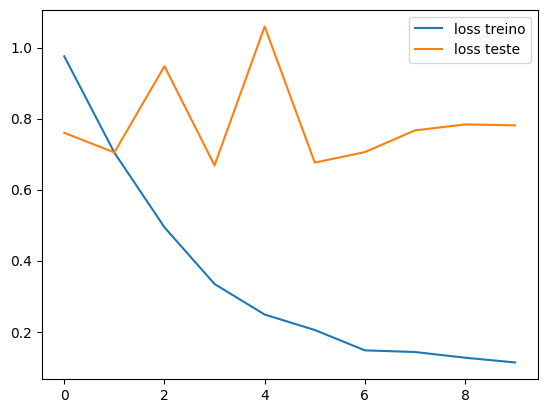

In [ ]:
plt.plot(loss_hist_complete, label="loss treino")
plt.plot(test_loss_list_complete, label="loss teste")
plt.legend()
plt.show()

---

### 8.2.4. Treinamento - 100 épocas

Treinamento com batches de épocas (de 10 em 10)

In [ ]:
# Definindo o otimizador como o BERT original
optimizer = torch.optim.AdamW(
    model.parameters(), lr=5e-5, eps=1e-8
)  # Igual ao Paper original do BERT

# MSE loss é o recomendado para regressão
loss_function = nn.MSELoss()

# Definindo número de épocas
epochs = 100
total_steps = len(train_dataloader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)

# Treinamento
model, loss_list, rmse_list, test_loss_list, test_rmse_list, best_loss = train_bert(
    model,
    optimizer,
    scheduler,
    loss_function,
    epochs,
    train_dataloader,
    test_dataloader,
    device,
    clip_value=2,
)


-----
EPOCH: 0
   BATCH: 0    LOSS: 5.311172891681973    RMSE: 2.3045982061266064
   BATCH: 1    LOSS: 1.8136122683445284    RMSE: 1.3467042245216758
   BATCH: 2    LOSS: 1.011859483696185    RMSE: 1.0059122644128486
   BATCH: 3    LOSS: 1.0387451735747624    RMSE: 1.0191884877561963
   BATCH: 4    LOSS: 0.4966251756332338    RMSE: 0.7047163795692801
   BATCH: 5    LOSS: 0.3885159424906415    RMSE: 0.6233104703842552
   BATCH: 6    LOSS: 0.6486756167128811    RMSE: 0.8054040083789509
   BATCH: 7    LOSS: 0.6958103818139973    RMSE: 0.8341524931413904
   BATCH: 8    LOSS: 0.6288671441290132    RMSE: 0.7930114400997083
   BATCH: 9    LOSS: 1.3239951234393876    RMSE: 1.150649870047091
   BATCH: 10    LOSS: 1.284205989930592    RMSE: 1.133228127929497
   BATCH: 11    LOSS: 0.978753226030473    RMSE: 0.9893195773007188
   BATCH: 12    LOSS: 7.682787354967863    RMSE: 2.771784146532313
   BATCH: 13    LOSS: 1.0238166946313485    RMSE: 1.0118382749389097
   BATCH: 14    LOSS: 0.667342731137

### 8.2.5. Resultados - 100 épocas

In [ ]:
def predict(model, dataloader, device):
  model.eval()
  output = []
  for batch in dataloader:
    batch_inputs, batch_masks, _ = tuple(b.to(device) for b in batch)
    with torch.no_grad():
      output += model(batch_inputs,
                      batch_masks).view(1,-1).tolist()[0]
  return output

In [ ]:
y_pred = predict(model, val_dataloader, device)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error

In [ ]:
rmse = root_mean_squared_error(val_labels, y_pred)

print('RMSE:', rmse)

RMSE: 0.9799661076573095


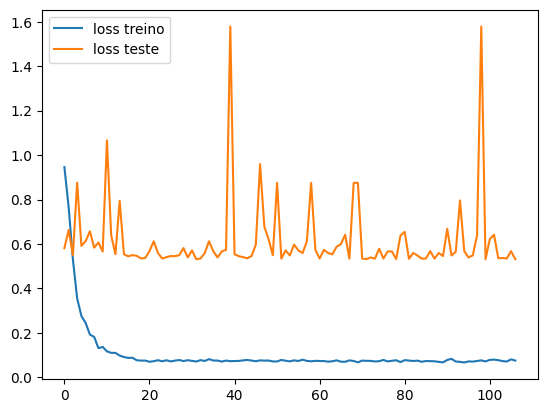

In [ ]:
plt.plot(loss_hist_complete, label='loss treino')
plt.plot(test_loss_list_complete, label='loss teste')
plt.legend()
plt.show()